In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
# load dataset 
df = pd.read_csv('dirty_cafe_sales.csv')
df.sample(5)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
1727,TXN_7864080,Tea,5,1.5,7.5,Credit Card,Takeaway,2023-11-12
1657,TXN_7730388,Cookie,5,1.0,5.0,Digital Wallet,In-store,2023-09-09
3294,TXN_5222110,Coffee,2,2.0,4.0,NaN,NaN,2023-01-30
7166,TXN_1971865,Cake,1,3.0,3.0,Digital Wallet,Takeaway,2023-04-11
8803,TXN_8343414,Salad,2,5.0,10.0,Credit Card,Takeaway,2023-02-28


In [3]:
df_overview = pd.DataFrame({
    'columns': df.columns,
    'type': df.dtypes,
    '# NaN': df.isna().sum(),
    '% NaN': (df.isna().sum() / df.shape[0]) * 100,
    '# unique values': df.nunique(),
    # ERROR/UNKNOWN are not NaN so they don't appear in the NaN count — check separately
    '# ERROR': (df == 'ERROR').sum(),
    '# UNKNOWN': (df == 'UNKNOWN').sum(),
})

df_overview

,columns,type,# NaN,% NaN,# unique values,# ERROR,# UNKNOWN
Transaction ID,Transaction ID,str,0,0.00,10000,0,0
Item,Item,str,333,3.33,10,292,344
Quantity,Quantity,str,138,1.38,7,170,171
Price Per Unit,Price Per Unit,str,179,1.79,8,190,164
Total Spent,Total Spent,str,173,1.73,19,164,165
Payment Method,Payment Method,str,2579,25.79,5,306,293
Location,Location,str,3265,32.65,4,358,338
Transaction Date,Transaction Date,str,159,1.59,367,142,159


In [4]:
# rename columns to snake_case for consistency
df.columns = ['transaction_id', 'item', 'quantity', 'price_per_unit', 'total_spent', 'payment_method', 'location', 'transaction_date']

In [5]:
# replace dirty string values with NaN

# 'ERROR' and 'UNKNOWN' are data entry errors in the source system and must be
# treated as missing before dtype conversion and missing-value handling.
# doing this here (before pd.to_numeric / dropna) ensures they flow through
# the pipeline as proper NaN and get imputed or dropped accordingly.

def replace_dirty_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replace 'ERROR' and 'UNKNOWN' strings with NaN across all columns.

    Args:
        df: Input DataFrame.

    Returns:
        DataFrame with ERROR and UNKNOWN replaced by pd.NA.
    """
    return df.replace({'ERROR': pd.NA, 'UNKNOWN': pd.NA})

df = replace_dirty_values(df)

In [6]:
# adjust dtypes

# ERROR/UNKNOWN are already NaN at this point (replaced in the cell above).
# pd.to_numeric(errors='coerce') handles any remaining non-numeric strings → NaN.
# pd.to_datetime(errors='coerce') handles unparseable dates → NaN.

float_columns: list[str] = ['price_per_unit', 'total_spent']

for col in float_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')

df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [7]:
# handling missing data

# step 1: drop columns with more than 40% missing values
# (none exceed this threshold in this dataset, but this step is required by the pipeline)
threshold = 0.4
df = df.dropna(thresh=int(len(df) * (1 - threshold)), axis=1)

# step 2: drop rows where critical columns have missing values (all below 10% NaN)
df = df.dropna(subset=['item', 'quantity', 'price_per_unit', 'total_spent', 'transaction_date'])

# step 3: impute remaining missing values with mode (payment_method ~26%, location ~33%)
str_columns = ['payment_method', 'location']
for col in str_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# check missing data
df_overview = pd.DataFrame({
    'columns': df.columns,
    'type': df.dtypes,
    '# NaN': df.isna().sum(),
    '% NaN': (df.isna().sum() / df.shape[0]) * 100,
    '# unique values': df.nunique()
})

df_overview

,columns,type,# NaN,% NaN,# unique values
transaction_id,transaction_id,str,0,0.0,7382
item,item,str,0,0.0,8
quantity,quantity,float64,0,0.0,5
price_per_unit,price_per_unit,float64,0,0.0,6
total_spent,total_spent,float64,0,0.0,17
payment_method,payment_method,str,0,0.0,3
location,location,str,0,0.0,2
transaction_date,transaction_date,datetime64[us],0,0.0,365


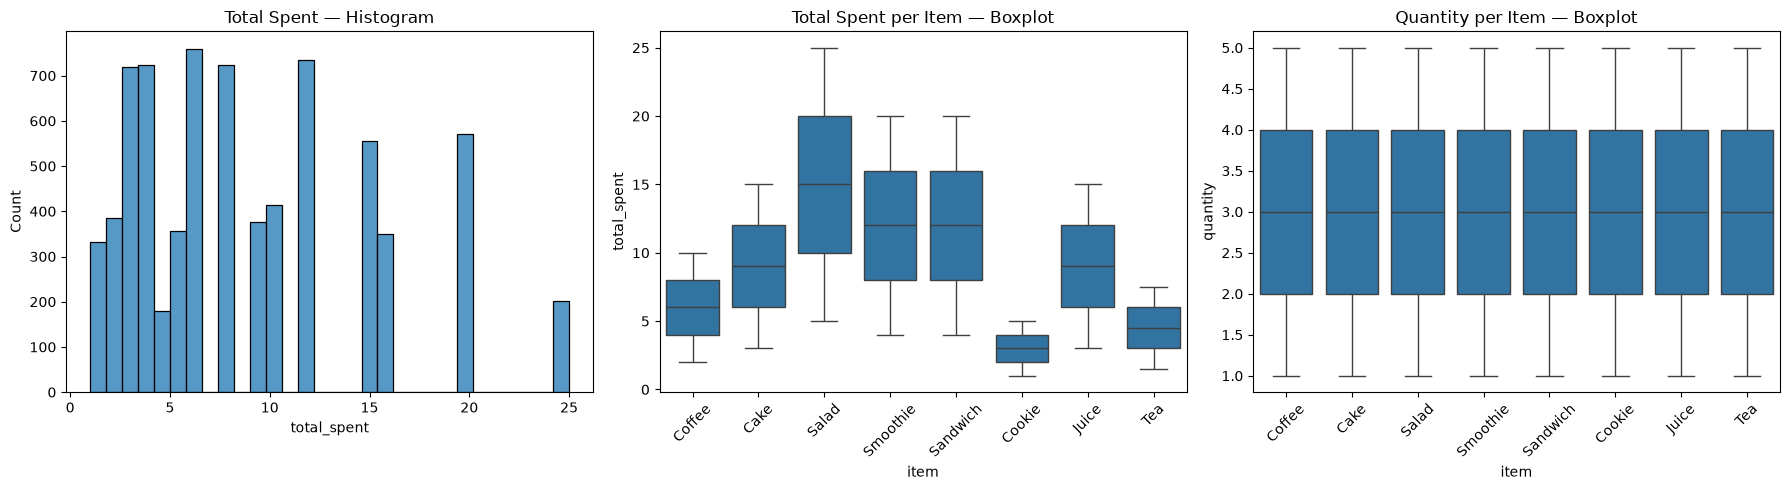

In [8]:
# check for outliers on total_spent(histogram), total spent per item, quantity per item
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. histogram: distribution of total_spent
axes[0].set_title('Total Spent — Histogram')
sns.histplot(df['total_spent'], bins=30, ax=axes[0])
axes[0].set_xlabel('total_spent')

# 2. boxplot: total_spent per item
axes[1].set_title('Total Spent per Item — Boxplot')
sns.boxplot(data=df, x='item', y='total_spent', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

# 3. boxplot: quantity per item
axes[2].set_title('Quantity per Item — Boxplot')
sns.boxplot(data=df, x='item', y='quantity', ax=axes[2])
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [9]:
print(f'Rows before removing outliers: {len(df)}')

# remove outliers with iqr

def remove_outliers(df: pd.DataFrame, column: str) -> pd.DataFrame:
    """
    Remove rows where the given column falls outside the IQR fence.

    Args:
        df: Input DataFrame.
        column: Name of the numeric column to filter.

    Returns:
        DataFrame with outlier rows removed.
    """
    q1: float = df[column].quantile(0.25)
    q3: float = df[column].quantile(0.75)
    iqr: float = q3 - q1

    lower: float = q1 - 1.5 * iqr
    upper: float = q3 + 1.5 * iqr

    return df[(df[column] >= lower) & (df[column] <= upper)]


df = remove_outliers(df, 'total_spent')

print(f'Rows after removing outliers: {len(df)}')

Rows before removing outliers: 7382
Rows after removing outliers: 7180


In [10]:
# normalize numeric columns
def normalize_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """
    Normalize numeric columns using MinMaxScaler to the range [0, 1].

    Preferred over StandardScaler when the distribution is unknown,
    as it makes no normality assumption.

    Args:
        df: Input DataFrame.
        columns: List of numeric column names to normalize.

    Returns:
        DataFrame with specified columns normalized in place.
    """
    
    scaler = MinMaxScaler()
    df[columns] = scaler.fit_transform(df[columns])
    
    return df


cols_to_normalize = ['quantity', 'price_per_unit', 'total_spent']
df = normalize_columns(df, cols_to_normalize)

df[cols_to_normalize].describe().round(2)

,quantity,price_per_unit,total_spent
count,7180.00,7180.00,7180.00
mean,0.49,0.47,0.39
std,0.35,0.31,0.29
min,0.00,0.00,0.00
25%,0.25,0.25,0.16
50%,0.50,0.50,0.34
75%,0.75,0.75,0.58
max,1.00,1.00,1.00


In [11]:
# encode categorical columns
# for ML we can drop id columns, so categorical columns remaining are: item, payment_method, location
# none are ordered, therefore we will use OneHot Encoding

# extract month from transaction_date before dropping it:
# raw datetime can't be used by ML models, but month captures seasonal patterns
# (e.g. higher sales in December) as a numeric feature
# year is dropped because this dataset only contains 2023 — a constant adds no information
df['month'] = df['transaction_date'].dt.month.astype(int)

# normalise month to [0, 1] to match the scale of the other numeric columns
df['month'] = (df['month'] - 1) / 11

df = df.drop(columns=['transaction_id', 'transaction_date'], errors='ignore')

df = pd.get_dummies(df, columns=['item', 'payment_method', 'location'], dtype=int)

df.head()

,quantity,price_per_unit,total_spent,month,item_Cake,item_Coffee,item_Cookie,item_Juice,item_Salad,item_Sandwich,item_Smoothie,item_Tea,payment_method_Cash,payment_method_Credit Card,payment_method_Digital Wallet,location_In-store,location_Takeaway
0,0.25,0.25,0.157895,0.727273,0,1,0,0,0,0,0,0,0,1,0,0,1
1,0.75,0.50,0.578947,0.363636,1,0,0,0,0,0,0,0,1,0,0,1,0
3,0.25,1.00,0.473684,0.272727,0,0,0,0,1,0,0,0,0,0,1,0,1
4,0.25,0.25,0.157895,0.454545,0,1,0,0,0,0,0,0,0,0,1,1,0
5,1.00,0.75,1.000000,0.181818,0,0,0,0,0,0,1,0,0,1,0,0,1
